In [1]:
from utils import * 
import numpy as np
from typing import NamedTuple
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
from ppi import *
import itertools
import os
import re
import networkx as nx
from hole import hole_main, hole_process_output

# find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +

%load_ext autoreload 
%autoreload 2

In [2]:
get_group_id = lambda node_id : node_id.split(':')[0]
get_ligand = lambda name : re.search('mg_(atp|adp)', name).group(1) if (re.search('mg_(atp|adp)', name) is not None) else 'no ligand'
get_edge_type = lambda contact_id : '-'.join(sorted([get_group_id(node_id) for node_id in contact_id.split('-')]))
get_cluster_1_count = lambda name : int(re.search(r'cluster_1_(\d+)mer', name).group(1))

In [3]:
# # Copy structures over for DALI search via the web interface. 
# for output_dir in glob.glob(os.path.join(ALPHAFOLD_DIR, 'server', '*')):
#     try:
#         output = AlphaFoldServerOutput(output_dir)

#         output_path = os.path.join('/home/prichter/Downloads/', f'{output.name}.pdb')
#         cif_to_pdb(output.best_model_path, output_path=output_path)
#     except:
#         continue

In [4]:
# It seems pretty clear that cluster_1 and cluster_3 proteins interact.
# I will aim to address the following questions:
#   (1) Are the predicted contacting residues between cluster_1 and cluster_3 the same in the hexameric structure versus the two monomers?
#   (2) Are there residues between cluster_1 and cluster_3 with high-confidence contact in the hexameric structure? 
#   (3) Are the contacting residues conserved in different genomes?
#   (4) Does the structure change in the presence or absence of ligands?

In [5]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r'))).astype(int)
genes_df['original_gene_id'] = genes_df.index.values
genes_df['gene_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}', axis=1)

genes_df = genes_df[genes_df.cluster_id.isin([1, 3])].copy()

SEQ_TO_GENE_ID_MAP = genes_df.set_index('seq').gene_id.to_dict()
SEQ_TO_CLUSTER_ID_MAP = genes_df.set_index('seq').cluster_id.to_dict()

In [6]:
# First, I want to use one of the genomes to determine the stoichiometry of the cluster_1 and cluster_3 monomers, and how ATP or ADP binding 
# alters the configuration. 

counts = [(0, 6), (2, 6), (1, 6), (3, 6), (12, 6), (6, 6)] # Counts for the cluster_1 and cluster_3 subunits, respectively. 
msas = get_msas_unpaired(genes_df.index)
inputs = list()

# for genome_id, df in genes_df[genes_df.genome_id.isin(['bz_0', 'bz_1'])].groupby('genome_id'):
for genome_id, df in genes_df.groupby('genome_id'):
    if genome_id != 'bz_2':
        continue
    df = df.sort_values('cluster_id') # Make sure cluster_1 is first. 
    cluster_1_entry = df[df.cluster_id == 1].iloc[0]
    cluster_3_entry = df[df.cluster_id == 3].iloc[0]

    for (cluster_1_count, cluster_3_count), ligand in itertools.product(counts, ['adp', 'atp', None]):

        name = f'{genome_id}_cluster_1_{cluster_1_count}mer-{genome_id}_cluster_3_{cluster_3_count}mer' + (f'-mg_{ligand}' if (ligand is not None) else '')
        name = name.replace('-', '_') # Fix this for the AlphaFold server. 
        
        input = AlphaFoldInputFile(name, version=2, num_seeds=1, dialect='alphafoldserver')
        # input = AlphaFoldInputFile(name, version=2, num_seeds=5, dialect='alphafold3')
        input.add_seq(cluster_1_entry.seq, n=cluster_1_count, unpaired_msa=msas[cluster_1_entry.original_gene_id])
        input.add_seq(cluster_3_entry.seq, n=cluster_3_count, unpaired_msa=msas[cluster_3_entry.original_gene_id])
        if ligand is not None:
            input.add_mg(n=cluster_3_count)
            input._add_ligand(type_=ligand, n=cluster_3_count)


with open('../data/genes/alphafold/af_input/cluster_1-cluster_3.json', 'w') as f:
    json.dump([input.get_info() for input in inputs], f)


In [7]:
msas = dict()
msas[1] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas[3] = MSAFile.from_file('../data/genes/cluster_3.afa')
# Replace the MSA gene IDs to match the grouped versions, e.g. bz_0_cluster_1.
msas[1].ids = genes_df.loc[msas[1].ids].gene_id.values
msas[3].ids = genes_df.loc[msas[3].ids].gene_id.values

contacts_df = pd.read_csv('analysis-1-ppi-level_1_conserved_contacts.csv')

contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
contacts_df = contacts_df[contacts_df.cluster_ids == 'cluster_1, cluster_3'].copy()

# For some reason, it seems as though chain A is not always cluster_1 and chain B is not always cluster_3... 
# So need to use the sequence to map the correct gene and cluster IDs individually. 
contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(SEQ_TO_GENE_ID_MAP)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['msa_residue_num_0'] = contacts_df.apply(lambda row : msas[row.cluster_id_0].map_idx_to_msa(row.residue_num_0, row.gene_id_0), axis=1)
contacts_df['msa_residue_num_1'] = contacts_df.apply(lambda row : msas[row.cluster_id_1].map_idx_to_msa(row.residue_num_1, row.gene_id_1), axis=1)

# Construct IDs for each contact which are comparable across genomes using the residue number from the MSA.
get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{row.msa_residue_num_0}', f'cluster_{row.cluster_id_1}:{row.msa_residue_num_1}']))
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


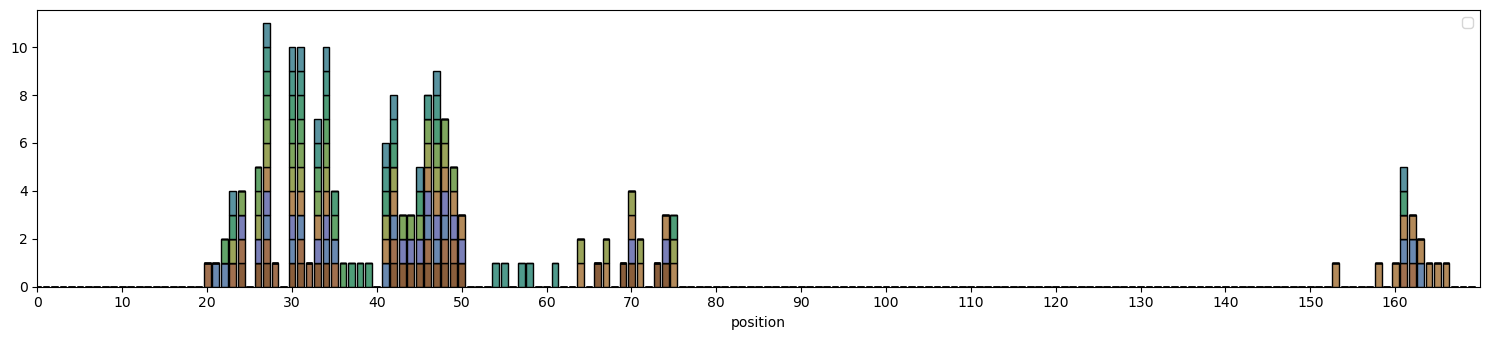

In [8]:
# figure_df = contacts_df.copy()
# figure_df['num_genomes_with_contact'] = figure_df.groupby('contact_id').genome_id.transform('nunique')
# figure_df = figure_df[figure_df.num_genomes_with_contact >= 7].copy()
# plot_contacts_graph(figure_df)

# First question is: is the cluster_1-cluster_3 binding interface consistent across stoichiometries?
x_max, x_min = 170, 0
group_id = 'cluster_1'
min_contact_prob = 0.5

figure_df = contacts_df.copy()
figure_df = figure_df[figure_df.contact_prob > min_contact_prob].copy()

fig, ax = plt.subplots(figsize=(15, 3.5), nrows=1)

bottom = np.zeros(x_max)
for genome_id, df in figure_df.groupby('genome_id', sort=False):
    try:
        heights = get_contact_profile(df, group_id=group_id, edge_types=['cluster_1-cluster_3'], metric='has_contact', max_position=x_max)
        color = 'lightgray' if (get_ligand(name) == 'adp') else 'gray'
        ax.bar(np.arange(len(heights)), heights, bottom=bottom, color=GENOME_ID_COLORS[genome_id], edgecolor='black')
        bottom += heights
    except Exception as err:
        print('No contacts for', name, err)

ax.set_xlabel('position')
ax.set_xticks(np.arange(x_min, x_max, 10))
ax.set_xlim(xmin=x_min, xmax=x_max)

ax.legend([])
fig.tight_layout()
plt.show()



get_supported_contacts: Maximum number of models supporting any contact is: 90
Number of supported contacts: 33
Number of genomes with a supported contact: 11


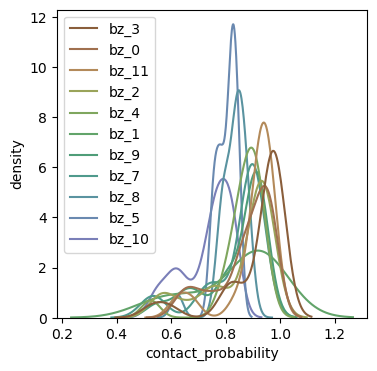

In [9]:
# Note that, because there are 10 seeds, there should be 10 models per genome, and 11 genomes with both cluster_1 and cluster_3. 
min_contact_prob = 0.5

def get_supported_contacts(contacts_df:pd.DataFrame, min_num_models:int=30, min_contact_prob=0.5):
    '''Obtain the contacts which are supported by at least min_num_models separate models.'''

    contacts_df = contacts_df[contacts_df.contact_prob > min_contact_prob].copy()
    contacts_df = contacts_df.drop_duplicates(['model', 'name', f'contact_id']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
    counts = contacts_df['contact_id'].value_counts()
    counts = counts[counts > min_num_models].copy()
    print(f'get_supported_contacts: Maximum number of models supporting any contact is:', counts.max())
    return sorted(counts.index.tolist())


supported_contact_ids = get_supported_contacts(contacts_df, min_contact_prob=min_contact_prob)
print('Number of supported contacts:', len(supported_contact_ids))
# print('\n'.join(supported_contact_ids))

fig, ax = plt.subplots(figsize=(4, 4))

figure_df = contacts_df[contacts_df.contact_prob > min_contact_prob].sort_values('contact_prob', ascending=False)
figure_df = figure_df[figure_df.contact_id.isin(supported_contact_ids)].copy()
print('Number of genomes with a supported contact:', figure_df.genome_id.nunique())

figure_df = figure_df.drop_duplicates(['contact_id', 'name', 'model']) # Keep one entry for each residue per model (the one with the highest probability).
sns.kdeplot(figure_df, x='contact_prob', hue='genome_id', common_norm=False)
ax.set_ylabel('density')
ax.set_xlabel('contact_probability')
ax.get_legend().set_title('')
plt.show()

In [10]:
# Before running a ton of AlphaFold jobs, I am going to do some exploratory analysis on one of the genomes. The questions which seem relevant are:
# (1) How does the stability of each complex change with the bound ligand? As a measure of "stability," the I could use PAE of contacting residues, 
#   number of contacting residues, or ipTM (ipTM is probably not great for comparing complexes, but could work to compare the ligands)
# (2) How does the stability of each complex compare to the baseline (no bound cluster_1). In order to compare the cluster_1-cluster_3 complexes to cluster_3-only 
#   multimers, using the cluster_3-cluster_3 edge PAE seems like the best metric. 

In [ ]:
# Want to look at the three different possible interfaces: cluster_1-cluster_3 interface, cluster_1-cluster_1 interface, and the cluster_3-cluster_3 interface. 

genome_id = 'bz_2'

if not os.path.exists(f'analysis-1-cluster_1-cluster_3-contacts_{genome_id}.csv'):
    contacts_df = list()
    # for output in tqdm(outputs, desc='Loading contact data.'):
    for path in tqdm(glob.glob(os.path.join('../data/genes/alphafold/server/', f'{genome_id}_cluster_1-{genome_id}_cluster_3', '*')), desc='Loading contact data.'):
        try:
            output = AlphaFoldServerOutput(path)
            contacts_df.append(get_contacts(output, min_contact_prob=0.3))
        except Exception as err:
            print(f'Skipping {os.path.basename(path)}, {err}.')
    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv(f'analysis-1-cluster_1-cluster_3-contacts_{genome_id}.csv', index=False)
else:
    contacts_df = pd.read_csv(f'analysis-1-cluster_1-cluster_3-contacts_{genome_id}.csv')

msas = dict()
msas[1] = MSAFile.from_file('../data/genes/cluster_1.afa')
msas[3] = MSAFile.from_file('../data/genes/cluster_3.afa')
# Replace the MSA gene IDs to match the grouped versions, e.g. bz_0_cluster_1.
msas[1].ids = genes_df.loc[msas[1].ids].gene_id.values
msas[3].ids = genes_df.loc[msas[3].ids].gene_id.values

contacts_df = contacts_df.dropna(axis=0) # Remove non protein-protein interactions. 
contacts_df['gene_id_0'] = contacts_df.seq_0.map(SEQ_TO_GENE_ID_MAP)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP).astype(int)
contacts_df['msa_residue_num_0'] = contacts_df.apply(lambda row : msas[row.cluster_id_0].map_idx_to_msa(row.residue_num_0, row.gene_id_0), axis=1)
contacts_df['msa_residue_num_1'] = contacts_df.apply(lambda row : msas[row.cluster_id_1].map_idx_to_msa(row.residue_num_1, row.gene_id_1), axis=1)

# get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{int(row.residue_num_0)}', f'cluster_{row.cluster_id_1}:{int(row.residue_num_1)}']))
get_contact_id = lambda row : '-'.join(sorted([f'cluster_{row.cluster_id_0}:{int(row.msa_residue_num_0)}', f'cluster_{row.cluster_id_1}:{int(row.msa_residue_num_1)}']))
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


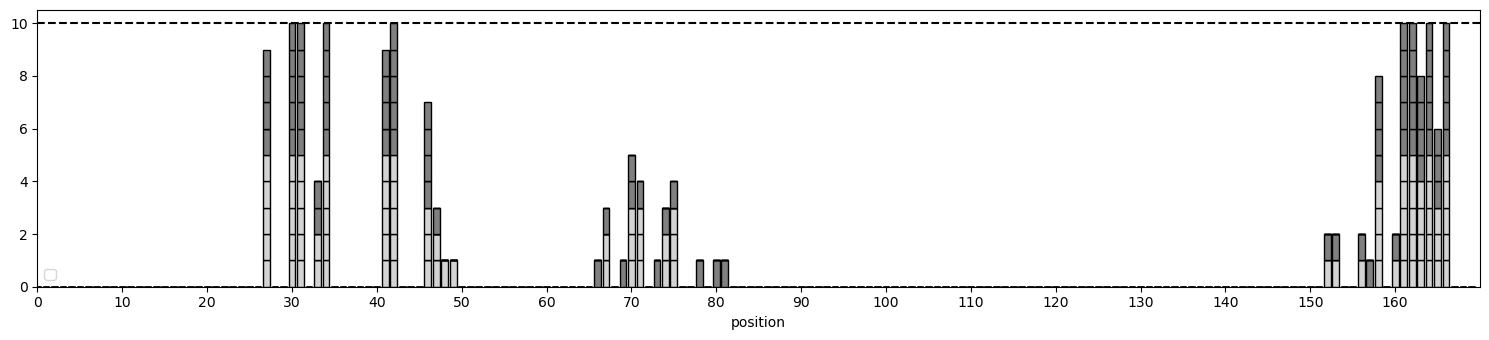

In [12]:
# First question is: is the cluster_1-cluster_3 binding interface consistent across stoichiometries?
x_max, x_min = 170, 0
ligands = ['adp', 'atp']
group_id = 'cluster_1'
min_contact_prob = 0.5

get_ligand = lambda name : re.search('mg_(atp|adp)', name).group(1) if (re.search('mg_(atp|adp)', name) is not None) else 'no ligand'
get_cluster_1_count = lambda name : int(re.search(r'cluster_1_(\d+)mer', name).group(1))

figure_df = contacts_df.copy()
figure_df['ligand'] = figure_df.name.apply(get_ligand)
figure_df = figure_df[figure_df.ligand.isin(ligands)].copy()
figure_df = figure_df[figure_df.contact_prob > min_contact_prob].copy()
figure_df = figure_df[~figure_df.name.str.contains('cluster_1_0mer')].copy() # Looking at cluster_1-cluster_3 interactions, so exclude this.
figure_df = figure_df.sort_values('ligand')

fig, ax = plt.subplots(figsize=(15, 3.5), nrows=1)

bottom = np.zeros(x_max)

for name, df in figure_df.groupby('name', sort=False):
    try:
        heights = get_contact_profile(df, group_id=group_id, edge_types=['cluster_1-cluster_3'], metric='has_contact', max_position=x_max)
        color = 'lightgray' if (get_ligand(name) == 'adp') else 'gray'
        ax.bar(np.arange(len(heights)), heights, bottom=bottom, color=color, edgecolor='black')
        bottom += heights
    except Exception as err:
        print('No contacts for', name, err)
# ax.bar(np.arange(len(heights)), heights, color='lightgray', edgecolor='black')

ax.axhline(figure_df.name.nunique(), color='black', ls='--')
ax.set_xlabel('position')
ax.set_xticks(np.arange(x_min, x_max, 10))
ax.set_xlim(xmin=x_min, xmax=x_max)

ax.legend([])
fig.tight_layout()
plt.show()

0 subunits:	 45 (adp), 58 (atp), 50 (no ligand)
1 subunits:	 45 (adp), 62 (atp), 49 (no ligand)
2 subunits:	 44 (adp), 61 (atp), 50 (no ligand)
3 subunits:	 47 (adp), 59 (atp), 46 (no ligand)
6 subunits:	 46 (adp), 56 (atp), 42 (no ligand)
12 subunits:	 45 (adp), 59 (atp), 41 (no ligand)


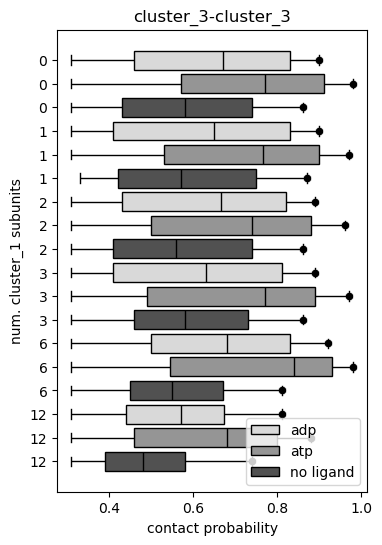

In [13]:
# What is the best way to compare these structures?
# For a given stoichiometry, which ligand state produces the most stable structure?

metric = 'contact_prob'
# metric = 'pae'
edge_type = 'cluster_3-cluster_3'

x_labels = {'pae':'PAE', 'contact_prob':'contact probability'}

figure_df = contacts_df[contacts_df.contact_prob > 0].copy()
figure_df['cluster_1_count'] = figure_df.name.apply(get_cluster_1_count)
figure_df['ligand'] = figure_df.name.apply(get_ligand)
figure_df['genome_id'] = figure_df.name.apply(get_genome_id)
figure_df['edge_type'] = figure_df.contact_id.apply(get_edge_type)
figure_df = figure_df[figure_df.edge_type == edge_type].copy()

if metric == 'pae':
    figure_df = figure_df.sort_values(['cluster_1_count', 'ligand', metric], ascending=[True, True, True])
else: # If metric is not PAE, want to pick the highest value of the metric to plot.
    figure_df = figure_df.sort_values(['cluster_1_count', 'ligand', metric], ascending=[True, True, False])


for n, df in figure_df.groupby('cluster_1_count'):
    df = df.drop_duplicates(['name', 'contact_id']) # Don't count contacts that are the same in cluster_1-cluster_3 pairs in a complex.
    counts = df.groupby('ligand').size().to_dict()
    counts = ', '.join([f'{count} ({ligand})' for ligand, count in counts.items()])
    print(f'{n} subunits:\t', counts)

fig, ax = plt.subplots(figsize=(4, 6))
sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays', linecolor='black', showfliers=False)
sns.scatterplot(figure_df.drop_duplicates(['name'], keep='first'), y='name', x=metric,color='black')


ax.set_ylabel('num. cluster_1 subunits')
ax.set_yticks(ax.get_yticks(), labels=[get_cluster_1_count(label.get_text()) for label in ax.get_yticklabels()])
ax.set_title(edge_type)
ax.set_xlabel(x_labels.get(metric, None))

plt.show()
# sns.barplot(figure_df, x='cluster_1_count', y='pae', hue='ligand', palette='Grays', edgecolor='black')

# There doesn't seem to be a strong interface between cluster_3 and cluster_1 with fewer than 6 subunits.

In [14]:
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_1-cluster_3'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

msas = get_msas_unpaired(genes_df.index)

inputs = list()
cluster_1_count, cluster_3_count = 6, 6 

names = list()
for genome_id, df in genes_df.groupby('genome_id'):
    df = df.sort_values('cluster_id') # Make sure cluster_1 is first. 
    cluster_1_entry = df[df.cluster_id == 1].iloc[0]
    cluster_3_entry = df[df.cluster_id == 3].iloc[0]

    name = f'{genome_id}_cluster_1_{cluster_1_count}mer-{genome_id}_cluster_3_{cluster_3_count}mer-mg_atp'

    input = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=10, version=2)
    input.add_seq(cluster_1_entry.seq, paired_msa='', unpaired_msa=msas[cluster_1_entry.original_gene_id], n=cluster_1_count)
    input.add_seq(cluster_3_entry.seq, paired_msa='', unpaired_msa=msas[cluster_3_entry.original_gene_id], n=cluster_3_count)
    input._add_ligand(type_='atp', n=cluster_3_count)
    input._add_ligand(type_='mg', n=cluster_3_count)

    names.append(input.name)
    input.write(os.path.join(ALPHAFOLD_INPUT_DIR, name + '.json'))

# 
# cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd = [f'run_alphafold3 --json_path=/root/af_input/cluster_1-cluster_3/bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_atp.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)


print('\n' + '\n'.join(names))

# for gene_id in names:
#     print(f'biotite get /home/philippar/af_output/{name}* /home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/', end='; ')

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/cluster_1-cluster_3/bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_atp.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"

bz_0_cluster_1_6mer-bz_0_cluster_3_6mer-mg_atp
bz_1_cluster_1_6mer-bz_1_cluster_3_6mer-mg_atp
bz_10_cluster_1_6mer-bz_10_cluster_3_6mer-mg_atp
bz_11_cluster_1_6mer-bz_11_cluster_3_6mer-mg_atp
bz_2_cluster_1_6mer-bz_2_cluster_3_6mer-mg_atp
bz_3_cluster_1_6mer-bz_3_cluster_3_6mer-mg_atp
bz_4_cluster_1_6mer-bz_4_cluster_3_6mer-mg_atp
bz_5_cluster_1_6mer-bz_5_cluster_3_6mer-mg_atp
bz_7_cluster_1_6mer-bz_7_cluster_3_6mer-mg_atp
bz_8_cluster_1_6mer-bz_8_cluster_3_6mer-mg_atp
bz_9_cluster_1_6mer-bz_9_cluster_3_6mer-mg_atp


In [ ]:
# output = AlphaFoldOutput('../data/genes/alphafold/af_output/bz_8_cluster_1_6mer-bz_8_cluster_3_6mer-mg_atp')
# output.get_chain_id_to_chain_map()


In [20]:
HOLE_INPUT_DIR = '../data/genes/hole/input'
HOLE_OUTPUT_DIR = '../data/genes/hole/output'    

cluster_3_chain_ids = list('GHIJKL')
cluster_1_chain_ids = list('ABCDEF')

# Based on looking at the structure, in order to preserve the orientation of the pore as used for the cluster_3 multimers, should use the cluster_1 chains
# and the following residue numbers. 
start_residue_num, end_residue_num = 90, 17


paths = list()
# Copy the CIF files to the HOLE_INPUT_DIR as PDB files, as HOLE only accepts PDB files.
for name in names:
    
    if not os.path.exists(os.path.join(ALPHAFOLD_OUTPUT_DIR, name)):
        print(f'Skipping {name}, as the AlphaFold output directory no longer exists.')
        continue

    output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
    models = sorted(list(output.model_paths))
    name = name.replace('-mg_atp', '') # Need to get rid of this or the HOLE input gets cut off. 

    for i, model in enumerate(models): # Need to replace the model name with an integer because of issues with input file line length limits.
        output_path = os.path.join(HOLE_INPUT_DIR, f'{name}.{i}.pdb')
        paths.append(cif_to_pdb(output.model_paths[model], output_path)) # Convert the CIF AlphaFold output to PDB and rename. 

paths = hole_main(paths, output_dir=HOLE_OUTPUT_DIR, chain_ids=cluster_1_chain_ids, start_residue_num=start_residue_num, end_residue_num=end_residue_num)

if not os.path.exists('analysis-1-cluster_1-cluster_3-hole.csv'):

    hole_df = list()
    for path in tqdm(paths, desc='Processing HOLE output.'):
        name = os.path.basename(path).replace('.pdb', '')
        hole_df.append(hole_process_output(name, input_dir=HOLE_INPUT_DIR, output_dir=HOLE_OUTPUT_DIR))

    hole_df = pd.concat(hole_df)
    hole_df.to_csv('analysis-1-cluster_1-cluster_3-hole.csv')


,residue_num,residue,chain_id,atom,coord,distance,sph_idx,name,hole_length
40942,2,PHE,J,CZ,"[10.334, -1.384, 29.476]",52.382747,310,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.0,105.071921
41201,2,PHE,K,CZ,"[13.36, -24.027, 14.907]",50.964739,310,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.0,105.071921
33321,2,PHE,I,CE1,"[-12.439, 15.012, 25.326]",47.706582,310,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.0,105.071921
41460,2,PHE,L,CZ,"[-4.752, -30.902, -4.286]",45.460872,310,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.0,105.071921
74480,111,GLU,F,OE1,"[-27.221, -31.119, 30.541]",9.363010,313,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.0,105.071921
...,...,...,...,...,...,...,...,...,...
32443,92,PHE,D,CE1,"[5.862, 5.599, 69.028]",47.829468,0,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.6,197.794424
7603,92,PHE,B,O,"[-12.517, 12.05, 70.203]",45.082908,0,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.6,197.794424
66950,93,LYS,E,NZ,"[2.202, 7.973, 74.958]",41.646984,0,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.6,197.794424
8204,93,LYS,F,O,"[-3.278, -11.12, 73.018]",41.508794,0,bz_7_cluster_1_6mer-bz_7_cluster_3_6mer.6,197.794424


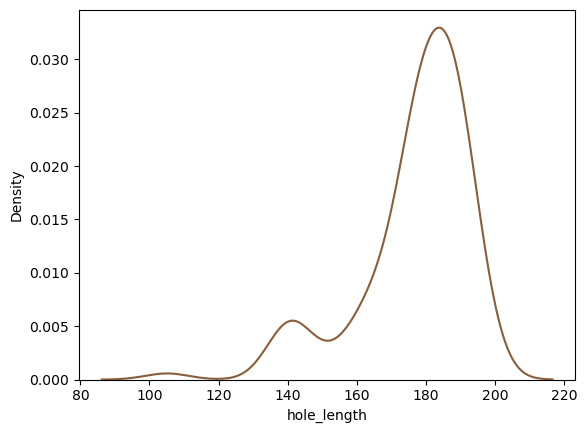

In [ ]:
sns.kdeplot(hole_df.hole_length.drop_duplicates())
hole_df.sort_values('hole_length')

hole_df = hole_df.groupby('')

In [ ]:
# x_max, x_min = 260, 0
# fig, ax = plt.subplots(figsize=(15, 4))

# for genome_id in ['bz_0', 'bz_8']:
#     name = f'{genome_id}_cluster_3_6mer_mg_atp'
#     plot_contact_profile(contacts_df[contacts_df.name == name], edge_types=['cluster_3-cluster_3'], ax=ax, color=GENOME_ID_COLORS[genome_id], x_max=x_max, label=genome_id)
    
# ax.legend()
# fig.tight_layout()
# plt.show()



In [ ]:
# # Looking at the ipTM score in these cases might not be particularly informative, as the comparatively low pTM scores for the 
# # cluster_1 proteins will drag down the mean of the complex. Instead, it is best to look directly at the interfaces. 
# # I want to consider how often a particular residue participates in a contact across different chain pairs and models, what it is contacting, 
# # and the contact probability, which is probably easiest with a graph. 

# # For each possible stoichiometry and ligand specification, I did the following analysis:
# #   (1) Obtain the residues with contact probability > 0.5 between each pair of chains. 
# #   (2) Construct an undirected graph based on the predicted contacts. 

# # (gene_id, residue_num, residue, contact_prob, model_name, pae) - (gene_id, residue_num, residue, contact_prob, model_name, pae)

# data = dict()

# def get_gene_id_map(token_chain_ids:np.ndarray, genes_df:pd.DataFrame=genes_df):
#     '''Use the lengths of each chain to map the chain IDs to the gene ID. Note that this is not ideal, but seems to be the simplest way to do this while
#     AlphaFold on biotite does not support chain descriptions.
    
#     :param token_chain_ids:
#     :param genes_df:
#     :returns:
#     '''
#     # Rename the gene IDs based on their cluster membership and genome. This is so that the edge IDs (below) are consistent across
#     # different genomes (i.e. cluster_1 always precedes cluster_3 in the ID)
#     genes_df.index = [f'{row.genome_id}_cluster_{int(row.cluster_id)}' for row in genes_df.itertuples()]

#     lengths = genes_df.seq.apply(len)
#     assert np.all(lengths.value_counts() == 1), f'get_gene_id_map: Protein lengths are not unique.'
#     lengths = lengths.reset_index(name='length').rename(columns={'index':'gene_id'}).set_index('length').gene_id.to_dict() #.gene_id.to_dict()
    
#     gene_id_map = dict()
#     for chain_id, length in zip(*np.unique(token_chain_ids, return_counts=True)):
#         gene_id_map[chain_id] = lengths.get(length, 'none')
#     return gene_id_map


# def get_residue(idx, token_chain_ids:np.ndarray):
#     '''

#     :param idx: The zero-indexed contact location relative to the token_chain_ids array. 
#     :param token_chain_ids: The token_chain_ids array from the AlphaFold output. 
#     :returns: A two-tuple containing (1) the chain ID and (2) zero-indexed residue number relative to the start of the chain. 
#     '''
#     chain_start_idxs = dict(zip(*np.unique(token_chain_ids, return_index=True))) # This is a dictionary mapping the chain IDs to their start indices.
#     chain_id = token_chain_ids[idx] # Get the chain that the specified index belongs to. 
#     return (chain_id, idx - chain_start_idxs[chain_id])


# def get_contacts(contact_probs_df:np.ndarray, min_contact_prob=0.3):
#     '''Use the contact_probs in the AlphaFold output to locate potential inter-chain residue contacts.
    
#     :param contact_probs_df: A square DataFrame containing the contact_probs for a given structure. 
#     :param min_contact_prob: The minimum contact_prob to say whether or not two residues are likely to be in contact. 
#     :returns:
#     '''
#     token_chain_ids = contact_probs_df.index.values
#     mask = (contact_probs_df.values > min_contact_prob) # Require a minimum contact probability. 
#     mask = mask & (np.expand_dims(token_chain_ids, axis=1) != np.expand_dims(token_chain_ids, axis=0))  # Don't include intra-chain contacts. 
#     # print(f'get_contacts: {mask.sum().sum()} inter-chain residues predicted to be in contact.')
#     return list(zip(*np.where(mask))) # Gets the contact indices as a list of two-tuples (i1, j1), (12, j2), ...


# def get_edge_id(row:dict):
#     '''Obtain an ID for an edge in the contact graph.

#     :param row: A dictionary containing row information for the contacts_df DataFrame (see below).
#     :returns: An "edge" ID, which encodes a contact between two proteins (not chains, i.e. when there are multiple chains per protein, 
#         these will map to the same edge ID). 
    
#     '''
#     node_ids = [row[f'gene_id_{i}'] + ':' + str(row[f'residue_num_{i}']) for i in range(2)]
#     node_ids = sorted(node_ids)
#     return '-'.join(node_ids)


# if not os.path.exists('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv'):
#     contacts_df = list()

#     # for output in outputs:
#     for output in tqdm(outputs, desc='Processing contact data.'):

#         contact_probs_df = output.get_contact_probs(best_model=True)
#         paes_df =  output.get_paes(best_model=True)
#         token_chain_ids = output.get_token_chain_ids()
#         # When constructing the gene ID map, need to filter by genome ID, as genes in different organisms have the same length. 
#         gene_id_map = get_gene_id_map(token_chain_ids, genes_df=genes_df[genes_df.genome_id == get_genome_id(output.name)])

#         for idxs in get_contacts(contact_probs_df):
#             row = dict()
#             for i, idx in enumerate(idxs):
#                 row[f'idx_{i}'] = idx 
#                 row[f'chain_id_{i}'], row[f'residue_num_{i}'] = get_residue(idx, token_chain_ids)
#                 row[f'gene_id_{i}'] = gene_id_map[row[f'chain_id_{i}']]
#             row['edge_id'] = get_edge_id(row)
#             row['pae'] = min(paes_df.iloc[idxs[0], idxs[1]], paes_df.iloc[idxs[1], idxs[0]]) # PAE is not symmetric. 
#             row['contact_prob'] = contact_probs_df.iloc[idxs[0], idxs[1]] # This should be symmetric. 
#             row['name'] = output.name 

#             contacts_df.append(row)

#     # Also want to take a look at the PAE distribution. 
#     contacts_df = pd.DataFrame(contacts_df)
#     contacts_df.to_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv', index=False)
# else:
#     contacts_df = pd.read_csv('analysis-1-cluster_1-cluster_3-bz_0_contacts.csv')


# name = 'bz_0_cluster_1_12mer_bz_0_cluster_3_6mer_mg_adp' # No PAE less than 22 between contacting residues in this structure. 

# filters = dict()
# # filters[f'not_{name}'] = contacts_df.name != name
# filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none')
# filters['not_cluster_3'] = ~((contacts_df.gene_id_0 == 'bz_0_cluster_3') & (contacts_df.gene_id_1 == 'bz_0_cluster_3')) 
# # filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
# filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

# # Interestingly, there does not seem to be any predicted contact between the bz_1 proteins, which is potentially problematic.
# # Reduced the minimum contact probability from 0.5 to 0.3 so that I could at least check the PAE.
# graph_df = apply_filters(filters, contacts_df)
# print('Number of contacts passing filters:', len(graph_df))

In [ ]:



# fig, axes = plt.subplots(figsize=(8, 8), nrows=2)
# plot_hydrophobicity(MSAFile.from_file('../data/genes/cluster_1.afa'), ax=axes[0], x_max=80, x_min=20)
# plot_hydrophobicity(MSAFile.from_file('../data/genes/cluster_3.afa'), ax=axes[1], x_max=215, x_min=50)

# axes[0].axvline(25, ls='--', color='black', lw=0.75)
# axes[0].axvline(30, ls='--', color='black', lw=0.75)
# axes[0].axvline(35, ls='--', color='black', lw=0.75)
# axes[0].axvline(50, ls='--', color='black', lw=0.75)
# axes[0].axhline(2, color='black', lw=0.75)
# axes[0].axhline(1, color='black', lw=0.75)
# axes[0].set_title('cluster_1')

# axes[1].axvline(65, ls='--', color='black', lw=0.75)
# axes[1].axvline(75, ls='--', color='black', lw=0.75)
# axes[1].axvline(200, ls='--', color='black', lw=0.75)
# axes[1].axvline(210, ls='--', color='black', lw=0.75)
# axes[1].axhline(2, color='black', lw=0.75)
# axes[1].axhline(1, color='black', lw=0.75)
# axes[1].set_title('cluster_3')


# fig.tight_layout()
# plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(5, 4))

# filters = dict()
# filters['non_atp_ligand'] = ~(contacts_df.name.str.contains('atp'))
# filters['non_protein_contact'] = (contacts_df.gene_id_0 == 'none') | (contacts_df.gene_id_1 == 'none') 
# filters['same_protein_contact'] = (contacts_df.gene_id_0  == contacts_df.gene_id_1)
# filters['low_contact_prob'] = contacts_df.contact_prob < 0.5

# figure_df = apply_filters(filters, contacts_df).copy()

# metric = 'pae'

# figure_df = apply_filters(filters, contacts_df).copy()

# conditions = [figure_df.name.str.contains('mg_atp'), figure_df.name.str.contains('mg_adp')]
# figure_df['ligand'] = np.select(conditions, ['ATP', 'ADP'], default='none')
# figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['edge_id', 'name'], keep='first')

# sns.boxplot(figure_df, y='name', x=metric, hue='ligand', palette='Grays')
# sns.stripplot(figure_df, y='name', x=metric, color='black')

# labels = ['-'.join(re.findall(r'\d+mer', label.get_text())) for label in ax.get_yticklabels()]
# ax.set_yticks(ax.get_yticks(), labels=labels)
# ax.set_ylabel('')
# ax.set_xlabel('PAE' if (metric == 'pae') else 'contact probability')

# plt.show()

In [ ]:
# fig, axes = plt.subplots(ncols=2, figsize=(15, 4), sharey=False)

# keep = lambda name : (genome_id in name)

# for data_ in data.values():

#     if not keep(data_['name']):
#         continue 
#     name = data_['name'].replace(f'fold_{genome_id}_', '').replace(f'{genome_id}_', '')


#     n = data_['num_contacts']

#     # print(f'Maximum contact probability for {name}:', max(data_['contact_probs']))
#     print(f'Number of contacts for {name} with > 70% probability:', (np.array(data_['contact_probs']) > 0.7).sum())
#     if len(data_['pae']) < 2:
#         print(f'Skipping {name}, only one contact found.')
#         continue

#     sns.kdeplot(data_['pae'], label=f'{name} (n={n})', ax=axes[0])
#     sns.kdeplot(data_['contact_probs'], label=f'{name} (n={n})', ax=axes[1])

# axes[1].legend(bbox_to_anchor=(1.1, 0.6))

# axes[0].set_ylabel('density')
# axes[1].set_ylabel('density')

# axes[0].set_title('PAE')
# axes[1].set_title('contact probability')

# fig.tight_layout()
# plt.show()


In [ ]:

# cluster_1_gene_id = CLUSTER_1_GENE_IDS[genome_id]
# cluster_3_gene_id = CLUSTER_3_GENE_IDS[genome_id]

# dssp_df = [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_1_gene_id}.dssp')).to_df().assign(cluster_id=1)]
# dssp_df += [DSSPFile.from_file(os.path.join(DSSP_OUTPUT_DIR, f'{cluster_3_gene_id}.dssp')).to_df().assign(cluster_id=3)]
# dssp_df = pd.concat(dssp_df).rename(columns={'residue':'idx', 'aa':'residue'}).drop(columns=['chain', 'code'])
# dssp_df['idx'] = dssp_df['idx'] - 1 # Need to shift the index to be zero-indexed. 

# figure_df = pd.DataFrame()

# for name in [f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp', f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp']:

#     contacts = dict()
#     contacts[1] = np.unique(data[name]['idxs_shifted'][0])
#     contacts[3] = np.unique(data[name]['idxs_shifted'][1])

#     for cluster_id, idxs in contacts.items():
#         for idx in idxs:
#             residue = CLUSTER_1_SEQS[genome_id][idx] if (cluster_id == 1) else CLUSTER_3_SEQS[genome_id][idx]
#             figure_df.loc[f'{residue}{idx}', name] = True
#             figure_df.loc[f'{residue}{idx}', 'idx'] = idx
#             figure_df.loc[f'{residue}{idx}', 'residue'] = residue
#             figure_df.loc[f'{residue}{idx}', 'cluster_id'] = cluster_id

# figure_df = figure_df.fillna(False)
# index = figure_df.index.copy()
# figure_df = figure_df.merge(dssp_df, on=['cluster_id', 'idx', 'residue'], how='left')
# figure_df.index = index

# fig, axes = plt.subplots(ncols=2, figsize=(6, 8))

# label_map = dict()
# label_map[f'fold_{genome_id}_cluster_1_6mer_{genome_id}_cluster_3_6mer_mg_atp'] = '6-mer complex'
# label_map[f'fold_{genome_id}_cluster_1_1mer_{genome_id}_cluster_3_1mer_mg_atp'] = '1-mer complex'

# for ax, (cluster_id, df) in zip(axes, figure_df.groupby('cluster_id')):
#     sns.heatmap(df[list(label_map.keys())].astype(int), ax=ax, cbar=False, cmap='binary')
#     ax.set_title(f'cluster {int(cluster_id)}')
#     ax.twinx().set_yticks(ax.get_yticks(), labels=df.structure.values[::-1])
#     ax.set_xticks(ax.get_xticks(), labels=[label_map.get(label.get_text()) for label in ax.get_xticklabels()])

# fig.tight_layout()
# plt.show()

In [ ]:
# def get_num_models_with_contact(contacts_df:pd.DataFrame, i:int=0, min_num_models:int=30):
#     '''Obtain the number of times a particular residue participates in an inter-chain contact across different models. 
#     In other words, if a residue participates in multiple contacts within the same model, only count the residue once.
#     Note that the model names themselves are not unique, so need to account for the names when de-duplicating. '''
#     contacts_df = contacts_df.drop_duplicates(['model', 'name', f'msa_residue_num_{i}']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
#     counts = contacts_df[f'msa_residue_num_{i}'].value_counts()
#     counts = counts[counts > min_num_models].copy()
#     return counts 

# def get_num_genomes_with_contact(contacts_df:pd.DataFrame, i:int=0):
#     '''Obtain the number of times a particular residue participates in an inter-chain contact across different genomes.'''
#     # Only keep one instance of the interaction per genome. 
#     contacts_df = contacts_df.drop_duplicates(['genome_id', f'msa_residue_num_{i}']) # Use the residue number mapped to the MSA so that they are comparable across genomes. 
#     counts = contacts_df[f'msa_residue_num_{i}'].value_counts()
#     return counts 

In [ ]:
# # There are 10 models per genome, so if a contact appears more than 10 times, it must appear in multiple genomes. 

# idxs = num_models_with_contact.index.values.astype(int)
# n = len(num_models_with_contact)
# print('Number of conserved contact residues:', n)

# fig, axes = plt.subplots(figsize=(n * 3, 3), ncols=n)

# for ax, idx in zip(axes, sorted(idxs)):
#     figure_df = contacts_df[contacts_df.msa_residue_num_0 == idx].copy()
#     sns.histplot(ax=ax, data=figure_df, x='residue_0', color='lightgray')
#     ax.set_title(f'position {idx}')

# # for ax, idx in zip(axes, sorted(idxs)):
# #     sns.histplot(ax=ax, x=msas[1].to_array().T[idx])
# #     ax.set_title(f'position {idx}')

# fig.tight_layout()

In [ ]:
# def plot_entropy(msa:MSAFile, max_entropy=0.1, x_min=20, x_max=70, ax:plt.Axes=None):

#     entropy = msa.get_entropy(alphabet=REDUCED_ALPHABET, exclude_gaps=True)

#     ax.plot(np.arange(len(entropy)), entropy, color='gray')

#     conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
#     # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
#     conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

#     for idx, aas in zip(conserved_idxs, conserved_aas):
#         if (idx > x_max) or (idx < x_min):
#             continue
#         # ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
#         ax.axvline(idx, color='black', lw=0.5)

#     x_ticks = np.arange(x_min, x_max, 2)
#     ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
#     ax.set_xlim(xmin=x_min, xmax=x_max)
#     ax.set_ylabel('entropy')
#     ax.set_xlabel('position')


# fig, axes = plt.subplots(figsize=(15, 6), nrows=2)
# plot_entropy(MSAFile.from_file('../data/genes/cluster_1.afa'), ax=axes[0], x_max=100, x_min=20)
# plot_entropy(MSAFile.from_file('../data/genes/cluster_3.afa'), ax=axes[1], x_max=215, x_min=50)

# axes[0].set_title('cluster_1')
# axes[1].set_title('cluster_3')

# fig.tight_layout()
# plt.show()
